<a href="https://colab.research.google.com/github/Sirrat21/Data-Science-Analytics_Internship_Tasks_PHASE-2/blob/main/Adv_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# **Exploratory Data Analysis (EDA)**

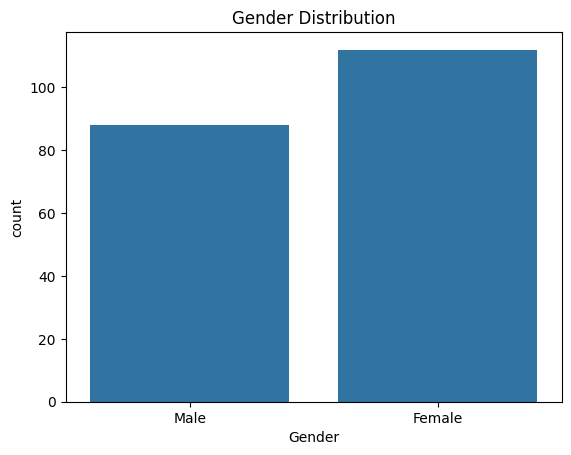

In [9]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

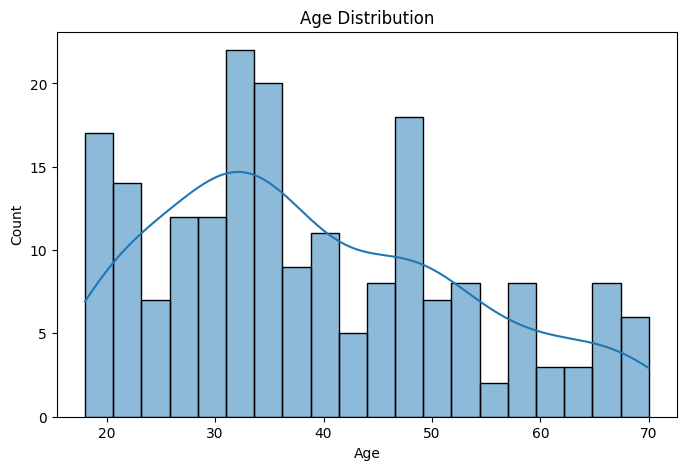

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

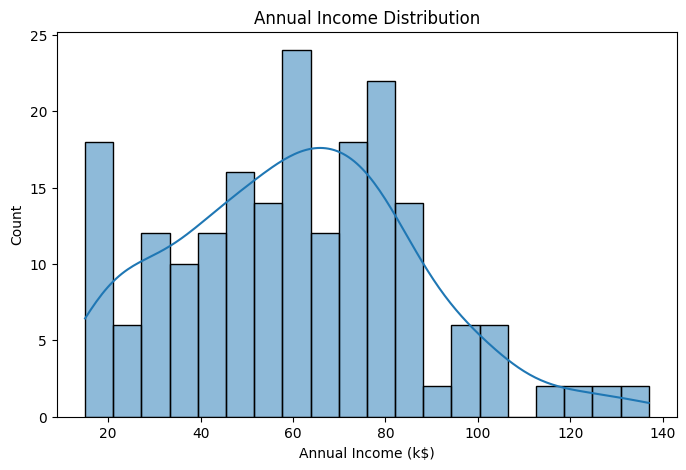

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()


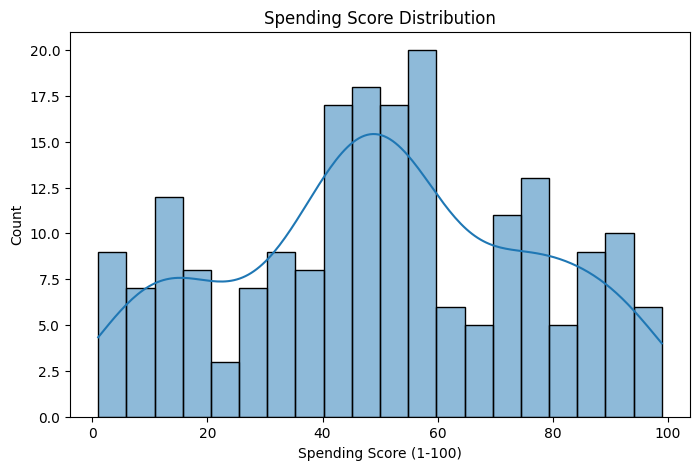

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

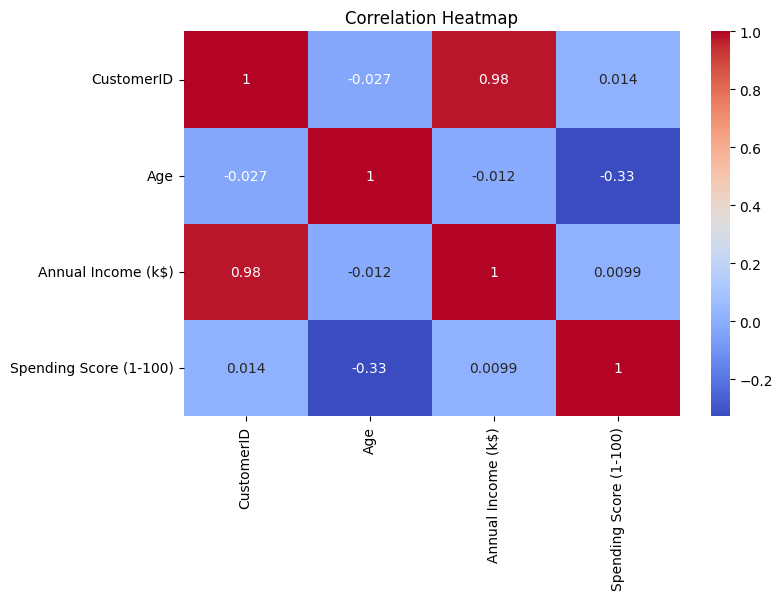

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Clustering**

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Optimal Number of Clusters through **Elbow Method**

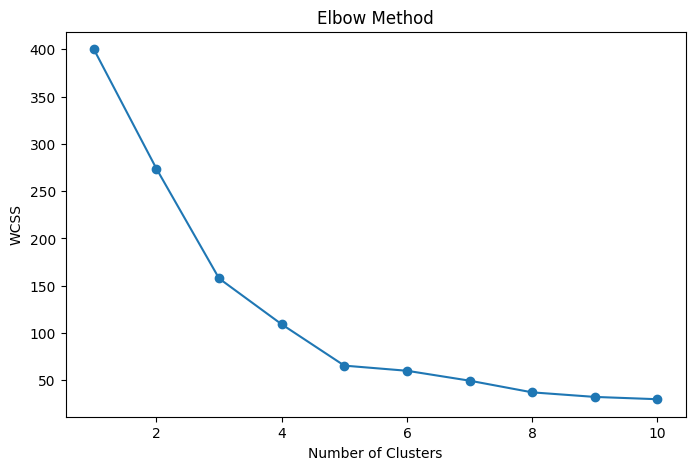

In [16]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# **K-Means Clustering**

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [19]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


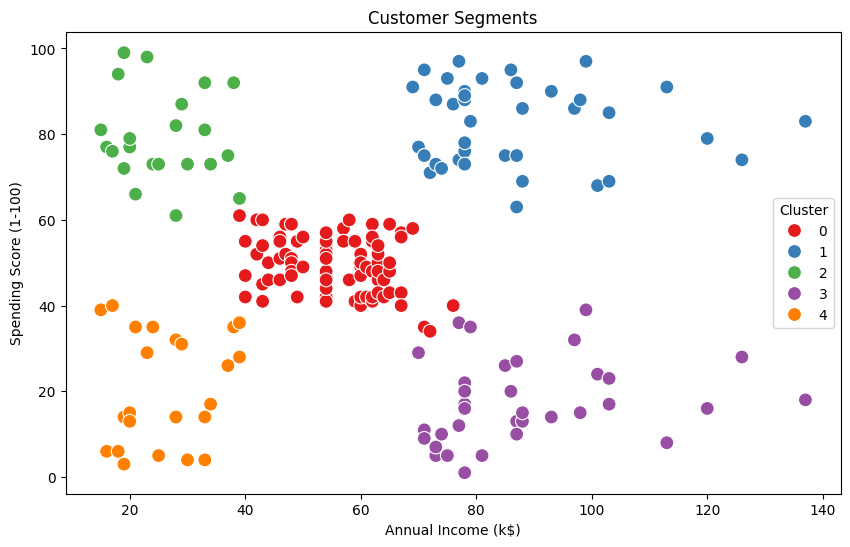

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segments")
plt.show()

In [21]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = clusters

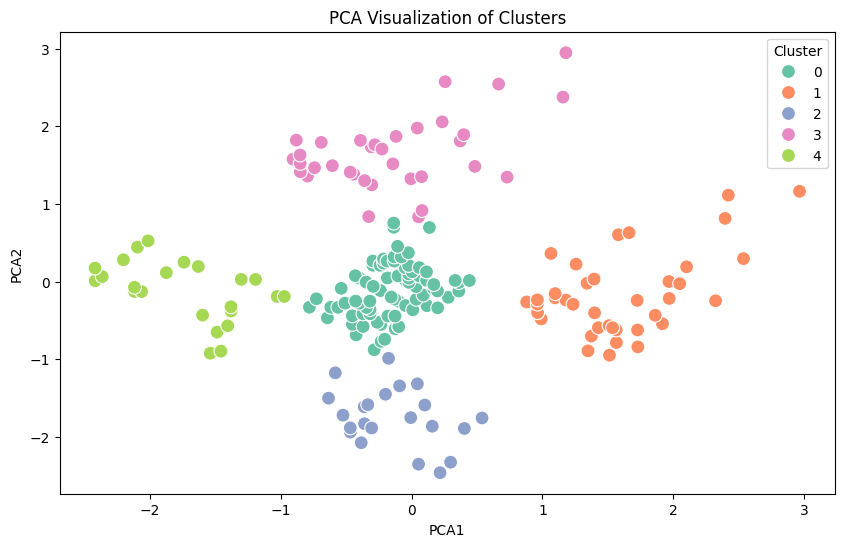

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set2',
    s=100
)

plt.title("PCA Visualization of Clusters")
plt.show()

In [23]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# **Marketing Strategies for Each Segment**

**Cluster 0 — High Income, High Spending Customers**

These customers spend a lot and have high income.

**Marketing Strategies:**
1. Premium membership offers
2. Luxury product recommendations
3. Exclusive discounts and VIP services

**Cluster 1 — Low Income, Low Spending Customers**

These customers spend less and have lower income.

**Marketing Strategies:**
1. Budget-friendly promotions
2. Discount coupons
3. Seasonal sale offers

**Cluster 2 — High Income, Low Spending Customers**

These customers have good income but spend less.

**Marketing Strategies:**
1. Personalized advertisements
2. Loyalty reward programs
3. Special product recommendations

**Cluster 3 — Low Income, High Spending Customers**

These customers spend actively despite lower income.

**Marketing Strategies:**
1. Flash sales
2. Combo offers
3. Social media marketing campaigns

**Cluster 4 — Average Customers**

These customers show average spending and income behavior.

**Marketing Strategies:**
1. General promotional campaigns
2. Regular engagement emails
3. Reward points system

# **Conclusion:**

1. K-Means clustering successfully segmented customers into 5 groups.

2. Customers were grouped based on Annual Income and Spending Score.

3. PCA helped visualize customer segments clearly.

4. Different customer groups showed different spending behaviors.

5. Businesses can use these insights to create targeted marketing strategies.